# Chapter 6: Knowledge Graphs as the Memory of Validation

The measurements produced by search and confirmation are used later by verification and reporting, and each use must be traceable to the artifact that produced the value. Chapter 6 develops the evidence store for this purpose: typed assertions bound to source files by digests and JSON pointers, with identifiers that preserve the study, split and metric of each value. This notebook works with the parallel projection that holds the mixture-model comparison and the regional medoid search under one contract.

The notebook rebuilds the store in memory and compares it with the saved store, inspects one regional record, checks its source hash and pointer, separates admission, discovery, confirmation and comparison records and repeats the chapter's mixture-model lookup with its lineage figure. No model is fitted, no embedding is trained and no language model is called.

**Evidence.** The store is in `book/evidence/parallel_aml_20260921/`. Its regional records come from `book/evidence/aml_medoid_loop_leaf_output_20260921/`, the run used in Chapters 2, 4 and 5. Its mixture-model records come from `book/evidence/aml_end_to_end_current_20260921/`. Both studies use synthetic AML populations.

**Run order.** Run the cells from top to bottom. Each assertion checks a rebuilt record, digest or value against the saved store or the chapter.

## Setup and source checks

Use a Python kernel with the dependencies listed in the README. The setup cell locates the data root, which holds the evidence files and helper modules. It uses `MODEL_VALIDATION_ROOT` when that variable is set. Otherwise it searches for a repository checkout containing the current directory and then for the copy installed with the `aiv` package.

`load()` checks the digests that link the regional results, frozen finalists, protocol and admission records. The store builder in `book/parallel_evidence/build.py` is imported as a module under the data root; it reads source files and writes nothing when called from this notebook.

In [1]:
from pathlib import Path
import os
import platform
import sys
import importlib.util

# Locate the data root: the directory whose relative layout the evidence records use.
MARKER = "book/notebooks/regional_case/companion.py"

def find_data_root():
    configured = os.environ.get("MODEL_VALIDATION_ROOT")
    if configured:
        root = Path(configured).expanduser().resolve()
        if not (root / MARKER).is_file():
            raise FileNotFoundError(f"MODEL_VALIDATION_ROOT must contain {MARKER}")
        return root, "MODEL_VALIDATION_ROOT"
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / MARKER).is_file():
            return path, "repository checkout"
    try:
        from aiv.companions import locate
    except ImportError:
        raise FileNotFoundError(
            "Companion data not found. Install the aiv package, open the notebook "
            "inside the repository checkout, or set MODEL_VALIDATION_ROOT.") from None
    return locate()

ROOT, DATA_SOURCE = find_data_root()
HELPERS = ROOT / "book/notebooks/regional_case"
for path in (ROOT, ROOT / "book", HELPERS):
    value = str(path)
    if value in sys.path:
        sys.path.remove(value)
    sys.path.insert(0, value)

# Load current helper files even if this kernel cached an older notebook revision.
def load_helper_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    try:
        spec.loader.exec_module(module)
    except Exception:
        sys.modules.pop(name, None)
        raise
    return module

load_helper_module("companion", HELPERS / "companion.py")
load_helper_module("ch02_helpers", HELPERS / "ch02_helpers.py")
load_helper_module("weighted_leaf_geometry", ROOT / "book/weighted_leaf_geometry.py")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
print("Python:", platform.python_version())
print("Data root found from:", DATA_SOURCE)
from companion import RUN, read, load, frontier, confirmation, measure, assignments
pd.set_option("display.float_format", "{:.6f}".format)
protocol, results, frozen = load()
print("Evidence:", RUN.relative_to(ROOT))
print("Mode: saved-evidence replay; no fitting or live LLM calls")


Python: 3.12.3
Data root found from: repository checkout
Evidence: book/evidence/aml_medoid_loop_leaf_output_20260921
Mode: saved-evidence replay; no fitting or live LLM calls


## Reconstruct the store

A validation report restates measured values, and a reviewer needs to recover each value from the artifact that produced it. Chapter 6 records such values as typed assertions in an evidence store (Section 6.1). Each assertion has a scoped identifier, an exact value, the source file that holds it, the file's SHA-256 digest and a JSON pointer to the field inside the file. The identifier's namespace records what the value measures and on which split, so a discovery score and a confirmation measurement of the same candidate never share an address.

The parallel store of Section 6.8.5 holds two predictive studies under one contract. The `moe` namespace holds the mixture-model comparison, whose objects are fitted predictors and whose metric is logloss. The `region` namespace holds the medoid search of Chapters 2, 4 and 5, whose objects are frozen membership rules for the fixed logistic predictor and whose metric is Brier contrast.

`construct()` in `book/parallel_evidence/build.py` builds the store in memory by reading each declared source field, recording its digest and pointer and checking the hash links between the regional results, frozen finalists, protocol and admission records. The first assertion requires the rebuilt store to equal the saved `store.json` exactly. The tables count records by study and by namespace.

In [2]:
from book.parallel_evidence.build import OUT, construct
store=read(OUT/"store.json")
assert store==construct()
counts=pd.Series({study:sum(k.startswith(study+":") for k in store["facts"]) for study in ["moe","region"]},name="facts")
assert counts.to_dict()=={"moe":50,"region":178}
display(counts)
display(pd.Series([k.split("/")[0] for k in store["facts"]]).value_counts().rename("records"))

moe        50
region    178
Name: facts, dtype: int64

region:confirmation    91
region:discovery       52
moe:confirmation       45
region:comparison      18
region:protocol         9
region:admission        5
moe:comparison          4
region:experiment       3
moe:protocol            1
Name: records, dtype: int64

**Read the output.** The rebuild reproduces the saved store, so every record can be regenerated from the source artifacts without fitting a model or calling a language model. The store holds 50 mixture-model records and 178 regional records. The regional namespaces separate 52 discovery records, 91 confirmation records, 18 comparison records, nine protocol records, five admission records and three experiment-level records. The two studies share the provenance contract; their metrics and selected objects keep distinct identities, as Table 6.3 of the chapter sets out.

## Inspect one assertion

A single record shows the contract. The chapter's worked lookup reads the confirmation contrast of the reflection arm at optimizer seed 73101, the union-rule branch of Chapter 5. As in the chapter listing, the cell prints the value to six decimals with its pointer. It then displays the complete record.

In [3]:
key="region:confirmation/reflection_73101/contrast"
record=store["facts"][key]
print(f"{record['value']:.6f}")
print(record["pointer"])
display(record)

0.058326
/confirmation/reflection_73101/contrast


{'value': 0.05832560853322555,
 'source': 'book/evidence/aml_medoid_loop_leaf_output_20260921/results.json',
 'source_sha256': 'fad0af92d04996ccb01f907412dc018c401f39d05443c608d862a5ff3209649b',
 'pointer': '/confirmation/reflection_73101/contrast'}

**Read the output.** The record gives the value 0.05832560853322555, displayed as 0.058326, together with the results file, its digest and the pointer `/confirmation/reflection_73101/contrast`. The store keeps the unrounded value; rounding is applied only when the value is displayed, so a report can round consistently while the verifier compares against the full value with a declared tolerance. The namespace `region:confirmation` identifies this as a measurement of the frozen region on confirmation observations.

## Resolve its provenance

A record is usable as evidence only if its source still says what the record claims. The check has two parts. The first recomputes the SHA-256 digest of the source file and compares it with the stored digest, which detects any change to the file since the store was built. The second parses the file and follows the JSON pointer, a path of keys and list indices, to the field, then requires that field to equal the stored value. `resolve` implements the pointer rules, including the escape sequences `~1` for a slash and `~0` for a tilde inside a key.

In [4]:
from companion import sha
from book.parallel_evidence.build import resolve
assert sha(ROOT/record["source"])==record["source_sha256"]
assert resolve(read(ROOT/record["source"]),record["pointer"])==record["value"]
print("hash and pointer agree:", record["source"], record["pointer"])

hash and pointer agree: book/evidence/aml_medoid_loop_leaf_output_20260921/results.json /confirmation/reflection_73101/contrast


**Read the output.** Both checks pass, so the stored value is the value in the unchanged results file. A failure of either check stops the pipeline, since the record could no longer be traced to its source. A successful check establishes what the executed artifact records. It does not establish that the simulator represents real AML behavior or that the language model's explanation for the union rule is correct.

## Preserve evidence status

Records about one candidate have different evidential status, and the store keeps them apart. Admission records state that a structural revision passed its checks and can be executed. Discovery records hold the values that guided selection, whereas confirmation records hold measurements of the frozen rule on new observations. Comparison records hold paired differences between arms.

The first display lists the admission records. The table then places the discovery and confirmation records of the seed-73101 reflection candidate side by side, with their pointers. The last table retrieves the three paired reflection-minus-continuation comparisons, and the assertion requires every interval to contain zero, as reported in Chapter 5.

In [5]:
display({k:v["value"] for k,v in store["facts"].items() if k.startswith("region:admission/")})
prefixes=["region:discovery/reflection_73101/","region:confirmation/reflection_73101/"]
display(pd.DataFrame([dict(id=k,value=v["value"],pointer=v["pointer"]) for k,v in store["facts"].items() if any(k.startswith(p) for p in prefixes)]))
rows=[]
for seed in protocol["seeds"]:
    base=f"region:comparison/reflection-continuation_{seed}/"
    lo,hi=store["facts"][base+"simultaneous_ci"]["value"]
    rows.append(dict(seed=seed,contrast_difference=store["facts"][base+"contrast_difference"]["value"],ci_low=lo,ci_high=hi))
paired=pd.DataFrame(rows)
assert all(paired.ci_low<=0) and all(paired.ci_high>=0)
display(paired)

{'region:admission/admitted': True,
 'region:admission/parent': 'leaf-output-medoid-single-cell-v1',
 'region:admission/version': 'leaf-output-medoid-union-v1',
 'region:admission/reason': 'A union of at most two cells from the same four-medoid partition preserves the frozen logistic predictor, auxiliary leaf-output embedding, observed covariates, Brier loss reference and all support checks. Membership uses only covariates and frozen output-space medoids. The new rule can be executed and scored without any new measurements. The fragmentation mechanism and performance prediction remain unverified.',
 'region:admission/response_sha256': 'ae5eeeb2ed78326e70d5b1e61ff41f8417982a0b383f5e6add3d68f3e0ebd3aa'}

,id,value,pointer
0,region:confirmation/reflection_73101/n,23044,/confirmation/reflection_73101/n
1,region:confirmation/reflection_73101/share,0.115220,/confirmation/reflection_73101/share
2,region:confirmation/reflection_73101/brier,0.072851,/confirmation/reflection_73101/brier
3,region:confirmation/reflection_73101/rest_brier,0.014525,/confirmation/reflection_73101/rest_brier
4,region:confirmation/reflection_73101/contrast,0.058326,/confirmation/reflection_73101/contrast
5,region:confirmation/reflection_73101/standard_...,0.001519,/confirmation/reflection_73101/standard_error
6,region:confirmation/reflection_73101/simultane...,"[0.05375692481013867, 0.06289429225631242]",/confirmation/reflection_73101/simultaneous_ci
7,region:discovery/reflection_73101/medoids,"[13, 1529, 1690, 2303]",/finalists/3/discovery/medoids
8,region:discovery/reflection_73101/region/cells,"[2, 3]",/finalists/3/discovery/region/cells
9,region:discovery/reflection_73101/region/share,0.116550,/finalists/3/discovery/region/share


,seed,contrast_difference,ci_low,ci_high
0,73101,0.000386,-0.001723,0.002495
1,73102,-0.003587,-0.007844,0.000669
2,73103,0.002373,-0.000913,0.005660


**Read the output.** The admission records hold the admitted flag, the parent and new versions, the reason and the digest of the saved response; none of them is a performance value. The discovery records give the frozen medoids, cells [2, 3], share 0.116550 and contrast 0.064412. The confirmation records give 23,044 members, share 0.115220, regional Brier 0.072851 against 0.014525 for the rest, contrast 0.058326 and its interval. Both sets are retained, so the lower confirmation contrast does not overwrite the discovery value. The comparison records reproduce the three paired differences, 0.000386, −0.003587 and 0.002373, whose intervals all contain zero. A report built from these records can therefore state that the rule was admitted without implying that it improved on continuation.

## Mixture-model lookup and the lineage figure

The same contract applies to the mixture-model comparison, a separate study of fitted predictors described in Appendix B. The chapter's first worked lookup reads its current projection in `book/evidence/aml_current/facts.json`, which keys each of 50 facts by entity and field. The cell retrieves the overall confirmation logloss of the `llm_compromise` endpoint, checks the source digest and prints the value and pointer as in the chapter.

The cell then confirms that the same value appears in the source results file at the recorded pointer and in the parallel store under `moe:confirmation/llm_compromise/overall_logloss`. It redraws Figure 6.2, the source-lineage diagram, from that value: frozen results with their digest, an entity and field bound by a pointer, the exact typed value and a claim comparison with provenance. Nothing is written to the book figures.

0.098260
/runs/llm/endpoints/compromise/confirmation/0


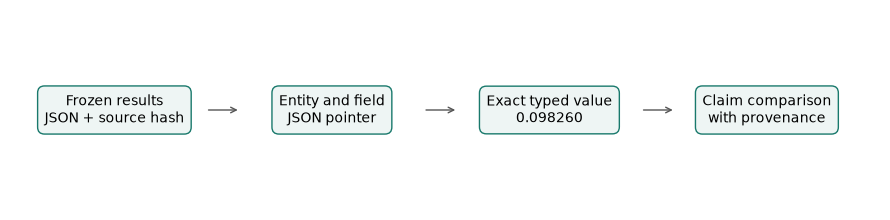

In [6]:
import hashlib, json
facts=json.loads((ROOT/"book/evidence/aml_current/facts.json").read_text())
assert len(facts)==50
moe=next(f for f in facts if f["entity"]=="llm_compromise" and f["field"]=="overall_logloss")
assert hashlib.sha256((ROOT/moe["source"]).read_bytes()).hexdigest()==moe["source_sha256"]
print(f"{moe['value']:.6f}")
print(moe["pointer"])
# The figure script reads the same results file and pointer; the parallel store holds the same value.
source=read(ROOT/"book/evidence/aml_end_to_end_current_20260921/results.json")
figure_value=source["runs"]["llm"]["endpoints"]["compromise"]["confirmation"][0]
assert moe["source"]=="book/evidence/aml_end_to_end_current_20260921/results.json"
assert figure_value==moe["value"]==store["facts"]["moe:confirmation/llm_compromise/overall_logloss"]["value"]
texts=["Frozen results\nJSON + source hash","Entity and field\nJSON pointer",f"Exact typed value\n{figure_value:.6f}","Claim comparison\nwith provenance"]
f,a=plt.subplots(figsize=(9,2.3));a.set_xlim(0,10);a.set_ylim(0,2);a.axis("off")
for i,t in enumerate(texts):
    x=.2+i*2.5;a.text(x+1,1,t,ha="center",va="center",fontsize=10,bbox=dict(boxstyle="round,pad=.5",fc="#eef5f4",ec="#19796c"))
    if i<3:a.annotate("",xy=(x+2.45,1),xytext=(x+2.05,1),arrowprops=dict(arrowstyle="->",color="#555555"))
f.tight_layout();plt.show()

**Read the output.** The lookup returns the chapter's value, 0.098260, at pointer `/runs/llm/endpoints/compromise/confirmation/0`. The results file and the parallel store hold the identical value. This is an overall logloss of a fitted mixture-model endpoint, so it cannot be compared with a regional Brier contrast even though both are stored under the same contract. The diagram shows the lineage of an exact fact. No geometric embedding is trained or used in this notebook.

## What the replay establishes

The evidence store has been rebuilt from its sources and one regional record and one mixture-model record have been traced to exact fields in unchanged files. The store separates admission, discovery, confirmation and comparison records, so the status of each value travels with it into later use.

Exact lookup by identifier is the operation used here. The chapter's geometric memory, which supports retrieval and plausibility assessment over stored relations, is a broader method that this notebook does not train or evaluate. Chapter 7 uses these records to verify claims, including claims that name a wrong split, a wrong metric or an unrecorded result.


## What to try

1. **A paired interval.** Take `region:comparison/reflection-continuation_73102/simultaneous_ci`, resolve its pointer in the source file with `resolve` and confirm that the value matches the record.
2. **Another seed.** List the discovery records of `reflection_73103` and report its medoids, cells, share and contrast. State whether its selected region is a union.
3. **Split identity.** Compare `region:discovery/reflection_73101/region/contrast` with `region:confirmation/reflection_73101/contrast`. Explain why a report quoting the discovery value as the confirmed contrast would misstate the evidence even though both records are correct.
4. **A missing record.** Search the store for a record of predictor repair or of a causal mechanism for the region. Explain what the absence of such a record should mean for a report.
